In [103]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from pathlib import Path
from PIL import Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [104]:
label_map = {
    "airplane": 0,
    "automobile": 1,
    "bird": 2,
    "cat": 3,
    "deer": 4,
    "dog": 5,
    "frog": 6,
    "horse": 7,
    "ship": 8,
    "truck": 9
}

In [105]:
train_labels = pd.read_csv("./cifar-10/trainLabels.csv").to_numpy()[:, 1]

In [106]:
folder = Path('./cifar-10/train')

def pull_data(folder):
    id_arr = []
    image_arr = []
    label_arr = []

    for file_path in folder.iterdir():
        # Make sure it's a file, not a subfolder
        if file_path.is_file():
            image = np.asarray(Image.open(file_path))
            file_name = file_path.name
            id = int(file_name[:file_name.index(".")])
            id_arr.append(id)
            image_arr.append(image)

    for id in id_arr:
        label = label_map[train_labels[id - 1]]
        label_arr.append(label)

    return id_arr, image_arr, label_arr

In [107]:
id_arr, image_arr, label_arr = pull_data(folder)

In [108]:
data = torch.Tensor(np.asarray(image_arr)).permute(0, 3, 1, 2)
labels = torch.Tensor(np.asarray(label_arr))
labels = labels.to(torch.uint8)

data.shape, labels.shape

(torch.Size([50000, 3, 32, 32]), torch.Size([50000]))

In [109]:
td = TensorDataset(data, labels)
td

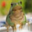

In [110]:
loader = DataLoader(td, batch_size=32)

batch_1 = next(iter(loader))

Image.fromarray(batch_1[0][0].permute(1, 2, 0).numpy().astype(np.uint8))

In [111]:
feature_extractor = nn.Sequential(
    nn.Conv2d(in_channels=3, out_channels=2, kernel_size=3, stride=1, padding=0),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2)
)

In [112]:
test_image = batch_1[0][0].unsqueeze(0)
test_image.shape

torch.Size([1, 3, 32, 32])

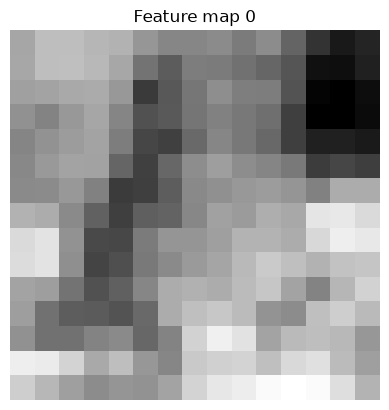

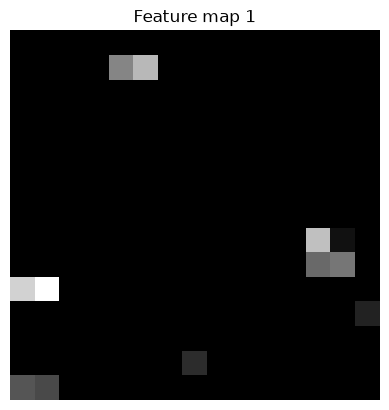

In [113]:
features = feature_extractor(test_image)

feature_maps = features[0].detach().cpu()

for i, feature_map in enumerate(feature_maps):
    plt.figure()
    plt.imshow(feature_map.numpy(), cmap="gray")
    plt.title(f"Feature map {i}")
    plt.axis("off")
    plt.show()

In [114]:
model = nn.Sequential(
    feature_extractor,
    nn.Flatten(),
    nn.Linear(450, 100),
    nn.ReLU(),
    nn.Linear(100, 10)
)

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

for epoch in range(40):
    running_loss = 0.0
    correct_cnt = 0
    total = 0

    for data, labels in loader:
        optimizer.zero_grad()

        pred = model(data)

        pred_labels = torch.argmax(pred, dim=1)

        correct_cnt += torch.sum(labels == pred_labels)
        total += pred.shape[0]

        loss = criterion(pred, labels)

        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
    running_loss /= len(loader) 
    print(f"Epoch {epoch+1}: {running_loss}")
    accuracy = correct_cnt / total

    print(
        f"Epoch {epoch + 1}: "
        f"loss={running_loss:.4f}, "
        f"accuracy={accuracy:.2%}"
    )

Epoch 1: 2.258232899453498
Epoch 1: loss=2.2582, accuracy=30.17%
Epoch 2: 1.6848754911032229
Epoch 2: loss=1.6849, accuracy=39.27%
Epoch 3: 1.5947383199070633
Epoch 3: loss=1.5947, accuracy=42.49%
Epoch 4: 1.5251839098378168
Epoch 4: loss=1.5252, accuracy=45.18%
Epoch 5: 1.4653003771794735
Epoch 5: loss=1.4653, accuracy=47.50%
Epoch 6: 1.4155729647561364
Epoch 6: loss=1.4156, accuracy=49.37%
Epoch 7: 1.3817025868845383
Epoch 7: loss=1.3817, accuracy=50.36%
Epoch 8: 1.3490271940112342
Epoch 8: loss=1.3490, accuracy=51.51%
Epoch 9: 1.3165705414513937
Epoch 9: loss=1.3166, accuracy=52.68%
Epoch 10: 1.3059549401833015
Epoch 10: loss=1.3060, accuracy=53.33%
Epoch 11: 1.2853549294416826
Epoch 11: loss=1.2854, accuracy=53.94%
Epoch 12: 1.26411450851139
Epoch 12: loss=1.2641, accuracy=54.76%
Epoch 13: 1.2514734510344263
Epoch 13: loss=1.2515, accuracy=55.24%
Epoch 14: 1.2431739220158533
Epoch 14: loss=1.2432, accuracy=55.55%
Epoch 15: 1.2213397215591817
Epoch 15: loss=1.2213, accuracy=56.38%
E